# **Section 7: Decision Trees Classification**

In this notebook, I will train and evaluate Decision Tree models. I will start with a baseline tree with default parameters, and will then tune the tree complexity (max_depth and min_samples_split) using a cross-validated grid search.

## **1. Importing the Data**

Let's import the training, validation, and test data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

sns.set_palette("pastel")

### **1.1 Load Features**

In [2]:
# Load features and labels
cnv_train = pd.read_csv("Data/cnv_train.csv", index_col=0)
cnv_test = pd.read_csv("Data/cnv_test.csv", index_col=0)
profiles_train = pd.read_csv("Data/SXT_train.csv", index_col=0)
profiles_test = pd.read_csv("Data/SXT_test.csv", index_col=0)

X_train = cnv_train.values
y_train = profiles_train.values

X_test = cnv_test.values
y_test = profiles_test.values

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Categories: {np.unique(y_train)}")

Training set shape: (173, 7197)
Test set shape: (48, 7197)
Categories: [0 1]


## **2. Decision Tree with Default Hyperparameters**

Let's start with a baseline Decision Tree using default parameters.

In [3]:
# Create Decision Tree (no scaling needed for trees)
dt = DecisionTreeClassifier(random_state=10)

# Train the model
dt.fit(X_train, y_train)

print("Decision Tree model trained")
print(f"Tree depth: {dt.get_depth()}")
print(f"Number of leaves: {dt.get_n_leaves()}")

Decision Tree model trained
Tree depth: 3
Number of leaves: 6


### **2.1 Evaluate Baseline Model**

In [4]:
# Evaluate on training, validation, and test sets
accuracy_train = dt.score(X_train, y_train)
accuracy_test = dt.score(X_test, y_test)

print(f"Accuracy training set: {accuracy_train:.4f}")
print(f"Accuracy test set: {accuracy_test:.4f}")

Accuracy training set: 1.0000
Accuracy test set: 0.8750


### **2.2 Feature Importance**

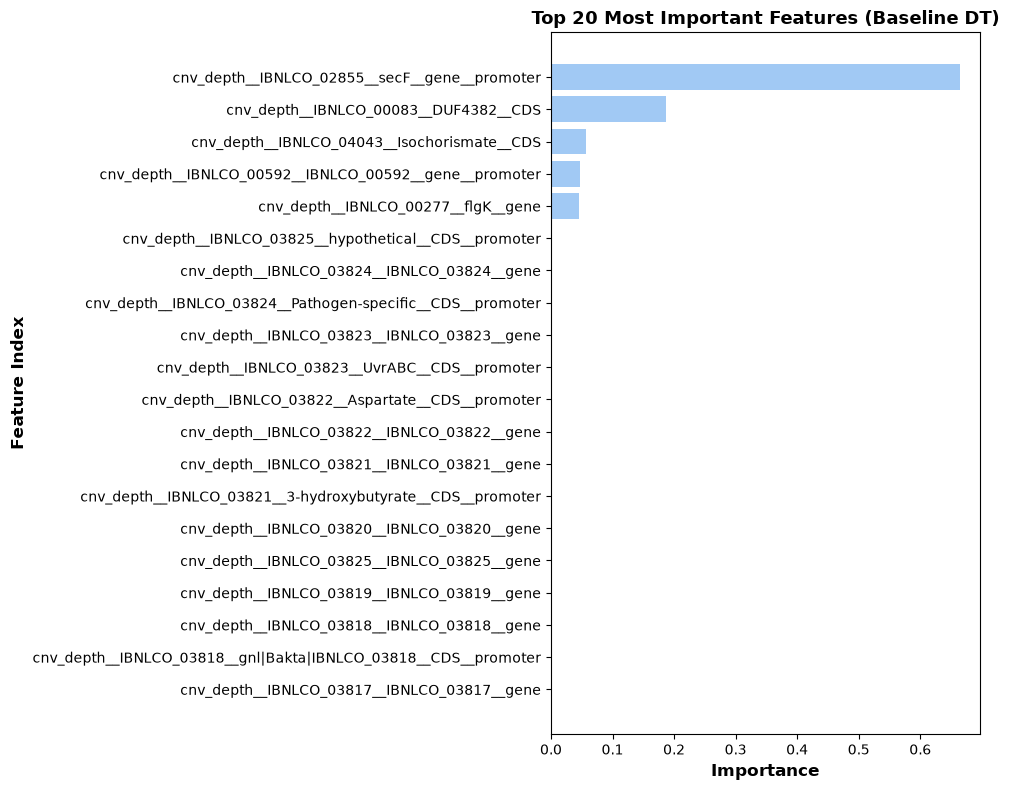


Top 10 most important features:
                                           feature_name  importance
3394      cnv_depth__IBNLCO_02855__secF__gene__promoter    0.663849
153               cnv_depth__IBNLCO_00083__DUF4382__CDS    0.187012
5032        cnv_depth__IBNLCO_04043__Isochorismate__CDS    0.056877
826   cnv_depth__IBNLCO_00592__IBNLCO_00592__gene__p...    0.046420
402                 cnv_depth__IBNLCO_00277__flgK__gene    0.045843
4805  cnv_depth__IBNLCO_03825__hypothetical__CDS__pr...    0.000000
4804        cnv_depth__IBNLCO_03824__IBNLCO_03824__gene    0.000000
4803  cnv_depth__IBNLCO_03824__Pathogen-specific__CD...    0.000000
4802        cnv_depth__IBNLCO_03823__IBNLCO_03823__gene    0.000000
4801     cnv_depth__IBNLCO_03823__UvrABC__CDS__promoter    0.000000


In [6]:
# Create a data frame with feature importances and names
feature_importance_df = pd.DataFrame({
    "feature_name": cnv_train.columns,
    "importance": dt.feature_importances_
}).sort_values("importance", ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance_df['importance'].head(20))
plt.yticks(range(20), feature_importance_df['feature_name'].head(20))
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature Index', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Important Features (Baseline DT)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feature_importance_df.head(10))

### **2.3 Classification Report and Confusion Matrix**

In [7]:
# Get predictions
y_test_pred = dt.predict(X_test)

# Classification report
print("Classification Report (Baseline DT):")
print(classification_report(y_test, y_test_pred))

Classification Report (Baseline DT):
              precision    recall  f1-score   support

           0       0.96      0.83      0.89        29
           1       0.78      0.95      0.86        19

    accuracy                           0.88        48
   macro avg       0.87      0.89      0.87        48
weighted avg       0.89      0.88      0.88        48



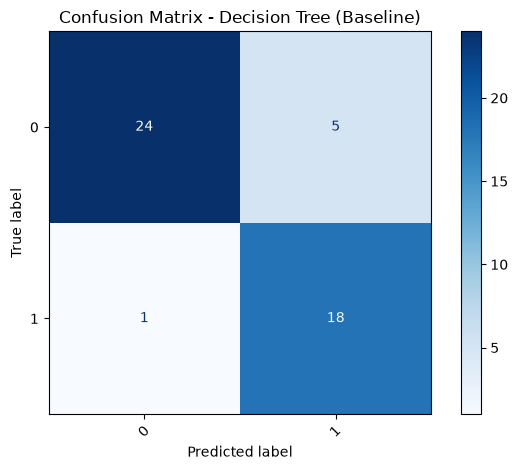

In [8]:
# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Decision Tree (Baseline)")
plt.tight_layout()
plt.show()

## **3. Hyperparameter Tuning: Controlling Tree Complexity**

Now let's use cross-validated grid search to tune tree complexity parameters (max_depth and min_samples_split).

### **3.2 Grid Search for Optimal Hyperparameters**

In [9]:
# Define parameter grid for tree complexity
param_grid = {
    'max_depth': [5, 7, 10, 12, 15],  
    'min_samples_split': [2, 5, 10, 20]
}

# Create grid search
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

# Perform grid search
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


Best parameters: {'max_depth': 5, 'min_samples_split': 20}
Best cross-validation score: 0.8383


### **3.3 Analyze Grid Search Results**

In [10]:
# Extract results
cv_results = pd.DataFrame(grid_search.cv_results_)

# Display top results
results_display = cv_results[[
    'mean_test_score', 'std_test_score', 
    'mean_train_score', 'std_train_score',
    'param_max_depth', 'param_min_samples_split'
]].sort_values('mean_test_score', ascending=False).head(10)

print("\nTop 10 Grid Search Results:")
print(results_display)


Top 10 Grid Search Results:
    mean_test_score  std_test_score  mean_train_score  std_train_score  \
3          0.838319        0.145121          0.985549         0.007938   
19         0.838319        0.145121          0.985549         0.007938   
11         0.838319        0.145121          0.985549         0.007938   
7          0.838319        0.145121          0.985549         0.007938   
15         0.838319        0.145121          0.985549         0.007938   
14         0.832437        0.143807          0.997122         0.005755   
2          0.832437        0.143807          0.997122         0.005755   
18         0.832437        0.143807          0.997122         0.005755   
10         0.832437        0.143807          0.997122         0.005755   
6          0.832437        0.143807          0.997122         0.005755   

    param_max_depth  param_min_samples_split  
3                 5                       20  
19               15                       20  
11             

### **3.4 Visualize Training/Validation Curves by Max Depth**

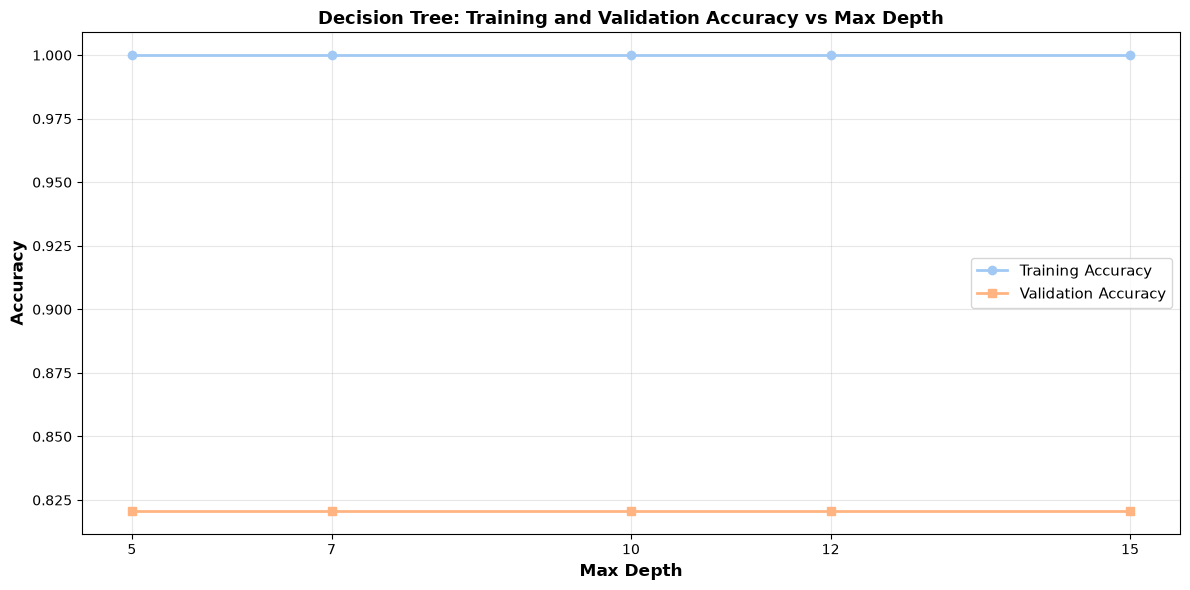

In [11]:
# Filter for min_samples_split=2
cv_results_filtered = cv_results[cv_results['param_min_samples_split'] == 2].sort_values('param_max_depth')

# Replace None with a large value for plotting
max_depths_plot = [d if d is not None else 100 for d in cv_results_filtered['param_max_depth']]
max_depths_labels = [str(d) if d is not None else 'None' for d in cv_results_filtered['param_max_depth']]

plt.figure(figsize=(12, 6))
plt.plot(
    max_depths_plot,
    cv_results_filtered['mean_train_score'],
    label='Training Accuracy',
    marker='o',
    linewidth=2
)
plt.plot(
    max_depths_plot,
    cv_results_filtered['mean_test_score'],
    label='Validation Accuracy',
    marker='s',
    linewidth=2
)

plt.xlabel('Max Depth', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Decision Tree: Training and Validation Accuracy vs Max Depth', fontsize=13, fontweight='bold')
plt.xticks(max_depths_plot, max_depths_labels)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/07_dt_training_curve.png", dpi=300)
plt.show()

## **4. Evaluate Best Model**

In [12]:
# Evaluate best model on test set
best_dt = grid_search.best_estimator_
accuracy_test_best = best_dt.score(X_test, y_test)

print(f"\nBest Model Test Accuracy: {accuracy_test_best:.4f}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")
print(f"Tree depth: {best_dt.get_depth()}")
print(f"Number of leaves: {best_dt.get_n_leaves()}")


Best Model Test Accuracy: 0.8958
Best parameters: {'max_depth': 5, 'min_samples_split': 20}
Best CV score: 0.8383
Tree depth: 3
Number of leaves: 5


### **4.1 Feature Importance of Best Model**

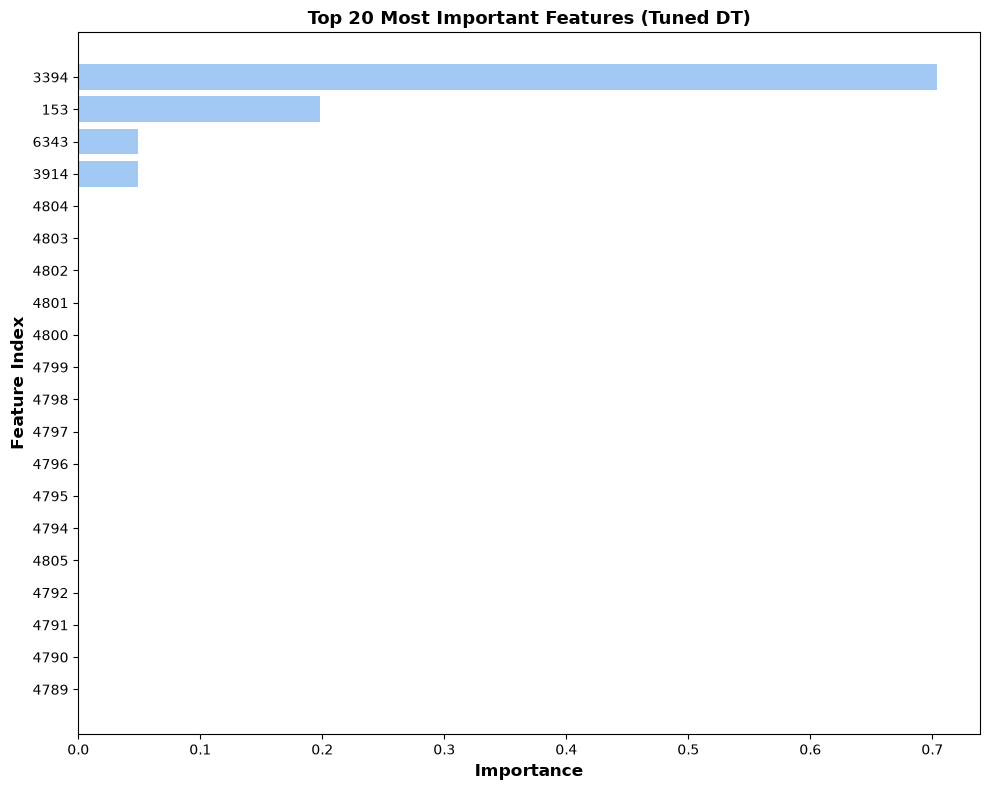


Top 10 most important features (tuned model):
      feature_index  importance
3394           3394    0.703883
153             153    0.198290
6343           6343    0.049219
3914           3914    0.048608
4804           4804    0.000000
4803           4803    0.000000
4802           4802    0.000000
4801           4801    0.000000
4800           4800    0.000000
4799           4799    0.000000


In [13]:
# Get feature importances
feature_importance_best = best_dt.feature_importances_
feature_importance_best_df = pd.DataFrame({
    'feature_index': range(len(feature_importance_best)),
    'importance': feature_importance_best
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(range(20), feature_importance_best_df['importance'].head(20))
plt.yticks(range(20), feature_importance_best_df['feature_index'].head(20))
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Feature Index', fontsize=12, fontweight='bold')
plt.title('Top 20 Most Important Features (Tuned DT)', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Figures/07_dt_feature_importance.png", dpi=300)
plt.show()

print("\nTop 10 most important features (tuned model):")
print(feature_importance_best_df.head(10))

### **4.2 Classification Report**

In [14]:
# Get predictions
y_test_pred_best = best_dt.predict(X_test)

# Classification report
print("\nClassification Report (Best DT):")
print(classification_report(y_test, y_test_pred_best))


Classification Report (Best DT):
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        29
           1       0.79      1.00      0.88        19

    accuracy                           0.90        48
   macro avg       0.90      0.91      0.89        48
weighted avg       0.92      0.90      0.90        48



### **4.3 Confusion Matrix**

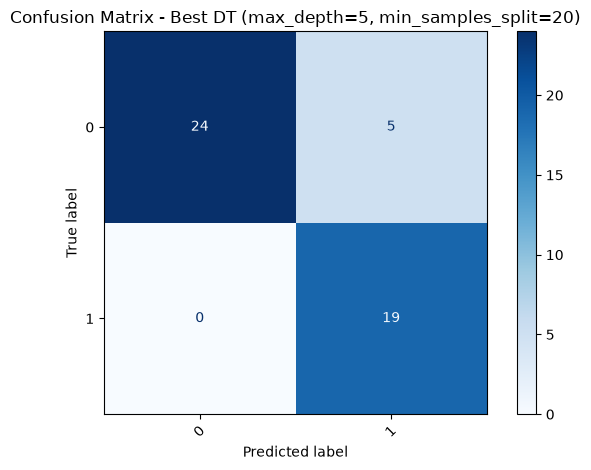

In [15]:
# Confusion matrix
cm_best = confusion_matrix(y_test, y_test_pred_best, labels=best_dt.classes_)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=best_dt.classes_)
disp_best.plot(cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - Best DT (max_depth={grid_search.best_params_['max_depth']}, min_samples_split={grid_search.best_params_['min_samples_split']})")
plt.tight_layout()
plt.savefig("Figures/07_dt_cm.png", dpi=300)
plt.show()

### **4.4 ROC Curve and AUC score**

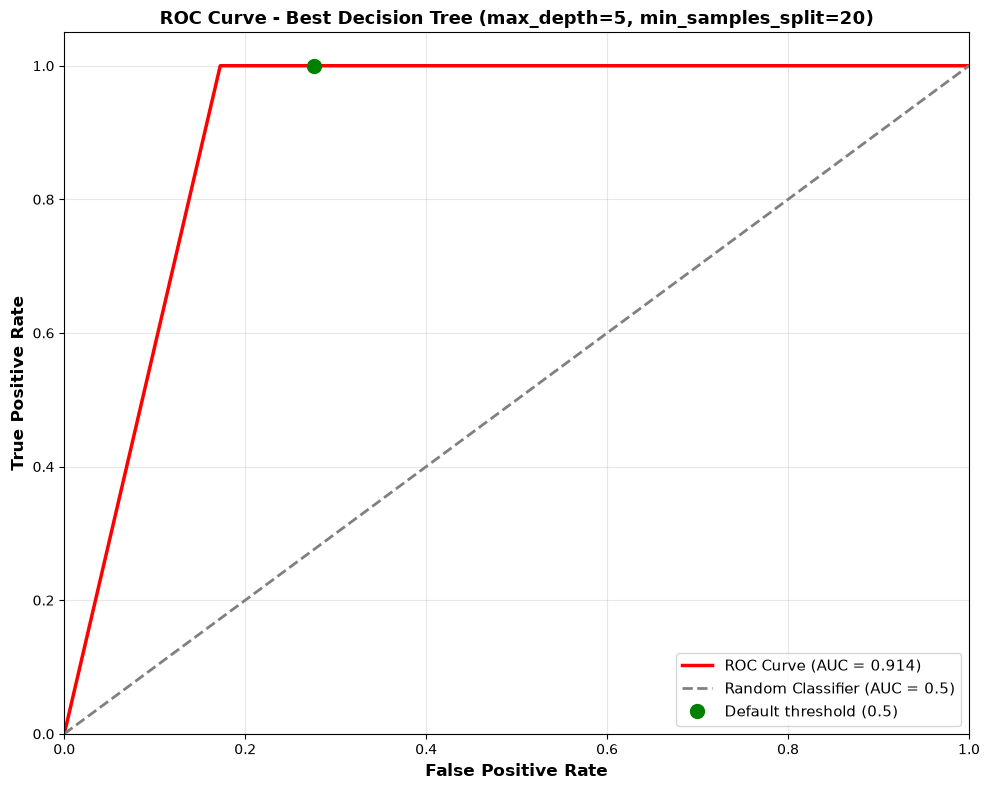


AUC Score: 0.9138
At default threshold (0.5):
  True Positive Rate (TPR): 1.000 (catch 100.0% of resistant)
  False Positive Rate (FPR): 0.276 (27.6% of susceptible misclassified)


In [16]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probability predictions for the positive class
y_test_proba = best_dt.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='red', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')

# Mark the default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.plot(fpr[default_idx], tpr[default_idx], 'go', markersize=10, label='Default threshold (0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'ROC Curve - Best Decision Tree (max_depth={grid_search.best_params_["max_depth"]}, min_samples_split={grid_search.best_params_["min_samples_split"]})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/07_dt_ROC.png", dpi=300)
plt.show()

print(f"\nAUC Score: {roc_auc:.4f}")
print(f"At default threshold (0.5):")
print(f"  True Positive Rate (TPR): {tpr[default_idx]:.3f} (catch {tpr[default_idx]*100:.1f}% of resistant)")
print(f"  False Positive Rate (FPR): {fpr[default_idx]:.3f} ({fpr[default_idx]*100:.1f}% of susceptible misclassified)")

## **5. Save Results**

In [18]:
import csv
import os

# Store results
results = {
    'model': 'Decision Tree',
    'hyperparameters': f"max_depth={grid_search.best_params_['max_depth']}, min_samples_split={grid_search.best_params_['min_samples_split']}",
    'test_accuracy': float(accuracy_test_best),
    'cv_score': float(grid_search.best_score_)
}

csv_file = 'Results/model_results.csv'

# Append results to the csv file
if not os.path.exists(csv_file):
    with open(csv_file, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writeheader()
        writer.writerow(results)
else:
    with open(csv_file, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['model', 'hyperparameters', 'test_accuracy', 'cv_score'])
        writer.writerow(results)

print(f"\nResults saved:")
print(f"  Model: {results['model']}")
print(f"  Hyperparameters: {results['hyperparameters']}")
print(f"  Test Accuracy: {results['test_accuracy']:.4f}")
print(f"  CV Score: {results['cv_score']:.4f}")


Results saved:
  Model: Decision Tree
  Hyperparameters: max_depth=5, min_samples_split=20
  Test Accuracy: 0.8958
  CV Score: 0.8383
